# Session 25: Linear, Ridge, Lasso, and Elastic Net

## Objective

Train four baseline regression models using the full-information
feature scenario and compare their test performance using MAE, RMSE,
and R-squared.

Models:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Elastic Net Regression

The main comparison metric is RMSE. Lower RMSE indicates better
test-set predictive performance.

This notebook is designed for local execution in VS Code. It does not
use Google Colab.


## 1. Imports and Project Paths


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLES_DIRECTORY = PROJECT_ROOT / "reports" / "tables"
FIGURES_DIRECTORY = PROJECT_ROOT / "reports" / "figures"

TABLES_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml


## 2. Load the Full-Information Modeling Data

The notebook first looks for saved Session 22 arrays. If they are not
available, it reconstructs the modeling data from a processed CSV file.


In [2]:
# Reconstruct full-information regression arrays locally
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

working_directory = Path.cwd()
project_root = (
    working_directory.parent
    if working_directory.name.lower() == "notebooks"
    else working_directory
)
data_directory = project_root / "data"

if not data_directory.exists():
    raise FileNotFoundError(f"Data directory not found: {data_directory}")

target_aliases = {
    "g3",
    "finalgrade",
    "grade",
    "target",
}

candidate_datasets = []

for csv_path in data_directory.rglob("*.csv"):
    try:
        frame = pd.read_csv(csv_path, sep=None, engine="python")
    except Exception:
        continue

    normalized_columns = {
        "".join(character for character in str(column).lower() if character.isalnum()):
        column
        for column in frame.columns
    }

    matched_target = next(
        (
            normalized_columns[alias]
            for alias in ["g3", "finalgrade", "grade", "target"]
            if alias in normalized_columns
        ),
        None,
    )

    if matched_target is None or len(frame) < 20:
        continue

    path_text = str(csv_path).lower()
    score = 0

    if "processed" in path_text:
        score += 400

    if "clean" in path_text:
        score += 300

    if "student-mat" in path_text:
        score += 200

    if len(frame) == 395:
        score += 100

    score += min(len(frame.columns), 100)

    candidate_datasets.append(
        (score, csv_path, frame, matched_target)
    )

if not candidate_datasets:
    raise KeyError(
        "No usable CSV containing G3, final_grade, grade, or target "
        "was found under the data folder."
    )

candidate_datasets.sort(
    key=lambda item: item[0],
    reverse=True,
)

_, csv_path, modeling_df, target_column = candidate_datasets[0]

print("Selected regression dataset:")
print(csv_path)
print("Regression target:", target_column)
print("Dataset shape:", modeling_df.shape)

y = pd.to_numeric(
    modeling_df[target_column],
    errors="coerce",
)

X_full = modeling_df.drop(
    columns=[target_column]
).copy()

valid_rows = y.notna()
X_full = X_full.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].reset_index(drop=True)

for column in X_full.select_dtypes(include=np.number).columns:
    X_full[column] = X_full[column].fillna(
        X_full[column].median()
    )

for column in X_full.select_dtypes(exclude=np.number).columns:
    X_full[column] = (
        X_full[column]
        .astype("string")
        .fillna("Unknown")
    )

X_full = pd.get_dummies(
    X_full,
    drop_first=False,
    dtype=float,
)

Xtr_f, Xte_f, ytr, yte = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=42,
)

def eval_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mse)),
        "R2": r2_score(y_true, y_pred),
    }

print("Reconstructed modeling arrays:")
print("Xtr_f shape:", Xtr_f.shape)
print("Xte_f shape:", Xte_f.shape)
print("ytr length:", len(ytr))
print("yte length:", len(yte))


Selected regression dataset:
C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml\data\processed\student_data_encoded.csv
Regression target: G3
Dataset shape: (395, 42)
Reconstructed modeling arrays:
Xtr_f shape: (316, 41)
Xte_f shape: (79, 41)
ytr length: 316
yte length: 79


## 3. Validate the Modeling Arrays


In [3]:
Xtr_f = np.asarray(Xtr_f, dtype=float)
Xte_f = np.asarray(Xte_f, dtype=float)
ytr = np.asarray(ytr, dtype=float).reshape(-1)
yte = np.asarray(yte, dtype=float).reshape(-1)

assert Xtr_f.ndim == 2
assert Xte_f.ndim == 2
assert Xtr_f.shape[0] == len(ytr)
assert Xte_f.shape[0] == len(yte)
assert Xtr_f.shape[1] == Xte_f.shape[1]
assert np.isfinite(Xtr_f).all()
assert np.isfinite(Xte_f).all()
assert np.isfinite(ytr).all()
assert np.isfinite(yte).all()

print("Session 25 modeling-array validation passed.")


Session 25 modeling-array validation passed.


## 4. Define the Regression Evaluation Helper


In [4]:
def eval_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }


print("eval_reg() is ready.")


eval_reg() is ready.


## 5. Scale the Features

Scaling is fitted on the training data only. The same fitted scaler is
then applied to the test data. This prevents test-set information from
leaking into model training.


In [5]:
scaler = StandardScaler()

Xtr_scaled = scaler.fit_transform(Xtr_f)
Xte_scaled = scaler.transform(Xte_f)

print("Training and test features were scaled correctly.")


Training and test features were scaled correctly.


## 6. Define and Train the Four Baseline Models


In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(
        alpha=1.0,
        max_iter=10000,
    ),
    "Elastic Net": ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=10000,
    ),
}

results = []
fitted_models = {}
test_predictions = {}

for model_name, model in models.items():
    model.fit(Xtr_scaled, ytr)
    predictions = model.predict(Xte_scaled)
    metrics = eval_reg(yte, predictions)

    fitted_models[model_name] = model
    test_predictions[model_name] = predictions

    results.append(
        {
            "Session": 25,
            "Model": model_name,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"],
        }
    )

    print(
        f"{model_name}: "
        f"MAE={metrics['MAE']:.4f}, "
        f"RMSE={metrics['RMSE']:.4f}, "
        f"R2={metrics['R2']:.4f}"
    )

print("All four baseline models were trained successfully.")


Linear Regression: MAE=1.6467, RMSE=2.3784, R2=0.7241
Ridge: MAE=1.6445, RMSE=2.3758, R2=0.7247
Lasso: MAE=1.4177, RMSE=2.2263, R2=0.7583
Elastic Net: MAE=1.5528, RMSE=2.3313, R2=0.7350
All four baseline models were trained successfully.


## 7. Rank the Baseline Models by RMSE


In [7]:
baseline_rows = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

baseline_rows.insert(
    2,
    "RMSE Rank",
    range(1, len(baseline_rows) + 1),
)

display(baseline_rows.round(4))


,Session,Model,RMSE Rank,MAE,RMSE,R2
0,25,Lasso,1,1.4177,2.2263,0.7583
1,25,Elastic Net,2,1.5528,2.3313,0.7350
2,25,Ridge,3,1.6445,2.3758,0.7247
3,25,Linear Regression,4,1.6467,2.3784,0.7241


## 8. Identify the Current Leading Baseline


In [8]:
best_row = baseline_rows.iloc[0]

print("Current leading baseline")
print("------------------------")
print("Model:", best_row["Model"])
print(f"MAE:  {best_row['MAE']:.4f}")
print(f"RMSE: {best_row['RMSE']:.4f}")
print(f"R2:   {best_row['R2']:.4f}")


Current leading baseline
------------------------
Model: Lasso
MAE:  1.4177
RMSE: 2.2263
R2:   0.7583


## 9. Save and Update the Model-Comparison Tables


In [9]:
session25_output_path = (
    TABLES_DIRECTORY
    / "session25_baseline_regression_rows.csv"
)

comparison_path = (
    TABLES_DIRECTORY
    / "model_comparison_table.csv"
)

baseline_rows.to_csv(
    session25_output_path,
    index=False,
)

if comparison_path.exists():
    comparison_table = pd.read_csv(comparison_path)

    if "Session" in comparison_table.columns:
        session_numbers = pd.to_numeric(
            comparison_table["Session"],
            errors="coerce",
        )

        comparison_table = comparison_table.loc[
            session_numbers != 25
        ].copy()
    elif "Model" in comparison_table.columns:
        comparison_table = comparison_table.loc[
            ~comparison_table["Model"].isin(
                baseline_rows["Model"]
            )
        ].copy()

    comparison_table = pd.concat(
        [comparison_table, baseline_rows],
        ignore_index=True,
        sort=False,
    )
else:
    comparison_table = baseline_rows.copy()

comparison_table.to_csv(
    comparison_path,
    index=False,
)

print("Session 25 table saved to:")
print(session25_output_path)

print("Model-comparison table saved to:")
print(comparison_path)


Session 25 table saved to:
C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml\reports\tables\session25_baseline_regression_rows.csv
Model-comparison table saved to:
C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml\reports\tables\model_comparison_table.csv


## 10. Compare Coefficient Behavior


In [10]:
coefficient_summary = []

for model_name, model in fitted_models.items():
    coefficients = np.asarray(model.coef_).reshape(-1)

    coefficient_summary.append(
        {
            "Model": model_name,
            "Number of Coefficients": len(coefficients),
            "Mean Absolute Coefficient": float(
                np.mean(np.abs(coefficients))
            ),
            "Maximum Absolute Coefficient": float(
                np.max(np.abs(coefficients))
            ),
            "Zero or Near-Zero Coefficients": int(
                np.isclose(
                    coefficients,
                    0.0,
                    atol=1e-8,
                ).sum()
            ),
        }
    )

coefficient_summary_df = pd.DataFrame(
    coefficient_summary
)

display(coefficient_summary_df.round(4))


,Model,Number of Coefficients,Mean Absolute Coefficient,Maximum Absolute Coefficient,Zero or Near-Zero Coefficients
0,Linear Regression,41,0.2155,3.5916,0
1,Ridge,41,0.2149,3.5533,0
2,Lasso,41,0.0771,3.1611,40
3,Elastic Net,41,0.0737,1.8324,38


## 11. Create the RMSE Comparison Figure


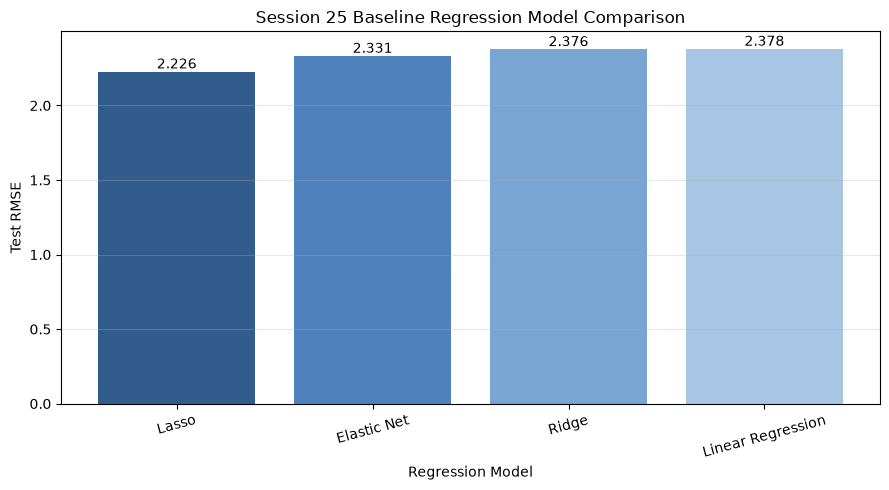

Figure saved to:
C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml\reports\figures\session25_baseline_rmse.png


In [11]:
plot_data = baseline_rows.sort_values("RMSE")

plt.figure(figsize=(9, 5))

bars = plt.bar(
    plot_data["Model"],
    plot_data["RMSE"],
    color=["#315C8C", "#4F81BD", "#78A5D1", "#A8C6E3"],
)

plt.title(
    "Session 25 Baseline Regression Model Comparison"
)
plt.xlabel("Regression Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_data["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

figure_path = (
    FIGURES_DIRECTORY
    / "session25_baseline_rmse.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:")
print(figure_path)


## 12. Reflection

If Ridge and Lasso perform almost the same as ordinary Linear
Regression, regularization is providing little immediate test-error
improvement under the current settings. The unregularized estimates
may already be sufficiently stable, multicollinearity may not be
seriously damaging prediction, or the default penalty strengths may
not be optimal.

Similar RMSE values do not mean that the models learned identical
coefficients. Ridge may shrink coefficients, while Lasso may set some
coefficients to zero. Model selection should therefore consider
cross-validation, coefficient stability, interpretability, and test
performance rather than RMSE alone.


## 13. Completion Validation


In [12]:
required_models = {
    "Linear Regression",
    "Ridge",
    "Lasso",
    "Elastic Net",
}

assert len(baseline_rows) == 4
assert set(baseline_rows["Model"]) == required_models
assert baseline_rows[
    ["MAE", "RMSE", "R2"]
].notna().all().all()
assert set(baseline_rows["RMSE Rank"]) == {1, 2, 3, 4}

print("SESSION 25 NOTEBOOK VALIDATION PASSED")


SESSION 25 NOTEBOOK VALIDATION PASSED


## Session 26 - KNN and SVR Regression

KNN and SVR are fitted with StandardScaler inside their pipelines.

In [13]:
# Session 26 imports
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [14]:
# Validate prerequisites
session26_required = ["Xtr_f", "Xte_f", "ytr", "yte", "eval_reg"]
session26_missing = [name for name in session26_required if name not in globals()]
if session26_missing:
    raise RuntimeError("Missing Session 26 prerequisites: " + ", ".join(session26_missing))
print("Session 26 prerequisites passed.")

Session 26 prerequisites passed.


In [15]:
# Fit and evaluate scaled models
session26_estimators = {
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
}
session26_models = {}
session26_records = []

for model_name, estimator in session26_estimators.items():
    pipeline = make_pipeline(StandardScaler(), estimator)
    pipeline.fit(Xtr_f, ytr)
    predictions = pipeline.predict(Xte_f)
    metrics = eval_reg(yte, predictions)
    if not isinstance(metrics, dict):
        raise TypeError("eval_reg must return a dictionary.")
    normalized = {
        str(key).strip().upper().replace("R^2", "R2").replace("R??", "R2"): value
        for key, value in metrics.items()
    }
    missing = [key for key in ["MAE", "RMSE", "R2"] if key not in normalized]
    if missing:
        raise KeyError("eval_reg is missing metrics: " + ", ".join(missing))
    session26_models[model_name] = pipeline
    session26_records.append({
        "Model": model_name,
        "MAE": float(normalized["MAE"]),
        "RMSE": float(normalized["RMSE"]),
        "R2": float(normalized["R2"]),
    })

session26_results_df = pd.DataFrame(session26_records)
display(session26_results_df.style.format({
    "MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"
}))

,Model,MAE,RMSE,R2
0,KNN,2.5848,3.3927,0.4387
1,SVR,1.8367,2.7260,0.6376


In [16]:
# Update comparison table without duplicates
if "comparison_df" not in globals():
    comparison_df = pd.DataFrame(columns=["Model", "MAE", "RMSE", "R2"])
if "Model" not in comparison_df.columns:
    raise KeyError("comparison_df has no Model column.")
comparison_df = comparison_df[
    ~comparison_df["Model"].astype(str).isin(["KNN", "SVR"])
].copy()
comparison_df = pd.concat([comparison_df, session26_results_df], ignore_index=True)
comparison_df = comparison_df.sort_values("RMSE", na_position="last").reset_index(drop=True)
display(comparison_df.style.format({
    "MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"
}))

,Model,MAE,RMSE,R2
0,SVR,1.8367,2.7260,0.6376
1,KNN,2.5848,3.3927,0.4387


In [17]:
# Final verification
assert isinstance(session26_models["KNN"].steps[0][1], StandardScaler)
assert isinstance(session26_models["SVR"].steps[0][1], StandardScaler)
assert comparison_df["Model"].astype(str).eq("KNN").sum() == 1
assert comparison_df["Model"].astype(str).eq("SVR").sum() == 1
assert {"Model", "MAE", "RMSE", "R2"}.issubset(comparison_df.columns)
print("SESSION 26 NOTEBOOK VERIFICATION PASSED")
print("Added models: KNN and SVR")
print("Scaling: StandardScaler is inside both pipelines")
print("KNN and SVR rows are present exactly once in comparison_df")

SESSION 26 NOTEBOOK VERIFICATION PASSED
Added models: KNN and SVR
Scaling: StandardScaler is inside both pipelines
KNN and SVR rows are present exactly once in comparison_df


<!-- SESSION_27_DECISION_TREE_BASELINE -->

## Session 27: Decision Tree Regression Baseline

This section trains a depth-limited Decision Tree regressor using
`max_depth=5` and `random_state=42`.

The model is evaluated on the existing full-information test set, and
its results are added to the regression model-comparison table.


In [18]:
# SESSION_27_DECISION_TREE_BASELINE

from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import re


# 1. Confirm that the earlier notebook objects are available.

required_objects = [
    "Xtr_f",
    "Xte_f",
    "ytr",
    "yte",
    "eval_reg",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Missing required objects: "
        + ", ".join(missing_objects)
        + ". Run the earlier preprocessing, splitting, and "
          "evaluation cells before running this cell."
    )


# 2. Train the Session 27 Decision Tree baseline.

tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=42,
)

tree.fit(Xtr_f, ytr)


# 3. Generate and evaluate test predictions.

tree_predictions = tree.predict(Xte_f)
tree_test_results = eval_reg(yte, tree_predictions)


def _session27_metric(result, *possible_names):
    """Read a metric while accommodating common key formats."""

    for name in possible_names:
        if name in result:
            return result[name]

    normalized_result = {
        re.sub(r"[^a-z0-9]+", "", str(key).lower()): value
        for key, value in result.items()
    }

    for name in possible_names:
        normalized_name = re.sub(
            r"[^a-z0-9]+",
            "",
            str(name).lower(),
        )

        if normalized_name in normalized_result:
            return normalized_result[normalized_name]

    raise KeyError(
        "Could not find any of these metric keys: "
        + ", ".join(possible_names)
    )


tree_mae = _session27_metric(
    tree_test_results,
    "MAE",
    "mae",
    "Test_MAE",
)

tree_rmse = _session27_metric(
    tree_test_results,
    "RMSE",
    "rmse",
    "Test_RMSE",
)

tree_r2 = _session27_metric(
    tree_test_results,
    "R2",
    "r2",
    "R-squared",
    "R²",
    "Test_R2",
)

print("Decision Tree test results:")
print(
    {
        "MAE": tree_mae,
        "RMSE": tree_rmse,
        "R2": tree_r2,
    }
)

print("Configured maximum depth:", tree.max_depth)
print("Actual fitted depth:", tree.get_depth())
print("Number of leaves:", tree.get_n_leaves())


# 4. Add exactly one Decision Tree row to the comparison table.

def _session27_normalize(value):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower(),
    )


field_aliases = {
    "model": {
        "model",
        "modelname",
    },
    "scenario": {
        "scenario",
        "dataset",
        "featureset",
        "featuregroup",
    },
    "parameters": {
        "parameters",
        "parameter",
        "hyperparameters",
        "configuration",
        "settings",
    },
    "mae": {
        "mae",
        "testmae",
        "meanabsoluteerror",
    },
    "rmse": {
        "rmse",
        "testrmse",
        "rootmeansquarederror",
    },
    "r2": {
        "r2",
        "testr2",
        "r2score",
        "rsquared",
    },
}

field_values = {
    "model": "Decision Tree",
    "scenario": "Full Information",
    "parameters": "max_depth=5; random_state=42",
    "mae": tree_mae,
    "rmse": tree_rmse,
    "r2": tree_r2,
}

candidate_table_names = [
    "model_comparison_df",
    "comparison_table",
    "regression_results_df",
    "results_df",
]

comparison_table_name = next(
    (
        name
        for name in candidate_table_names
        if name in globals()
        and isinstance(globals()[name], pd.DataFrame)
    ),
    None,
)

if comparison_table_name is None:
    model_comparison_df = pd.DataFrame(
        [
            {
                "Model": "Decision Tree",
                "Scenario": "Full Information",
                "Parameters": "max_depth=5; random_state=42",
                "MAE": tree_mae,
                "RMSE": tree_rmse,
                "R2": tree_r2,
            }
        ]
    )

    comparison_table_name = "model_comparison_df"
    updated_comparison_table = model_comparison_df

else:
    existing_table = globals()[comparison_table_name].copy()

    normalized_columns = {
        column: _session27_normalize(column)
        for column in existing_table.columns
    }

    row_values = {}

    for column, normalized_column in normalized_columns.items():
        matched_field = next(
            (
                field
                for field, aliases in field_aliases.items()
                if normalized_column in aliases
            ),
            None,
        )

        if matched_field is None:
            row_values[column] = pd.NA
        else:
            row_values[column] = field_values[matched_field]

    required_columns = {
        "model": "Model",
        "mae": "MAE",
        "rmse": "RMSE",
        "r2": "R2",
    }

    normalized_existing = set(normalized_columns.values())

    for field, default_column in required_columns.items():
        if not normalized_existing.intersection(
            field_aliases[field]
        ):
            existing_table[default_column] = pd.NA
            row_values[default_column] = field_values[field]

    model_column = next(
        (
            column
            for column, normalized_column
            in normalized_columns.items()
            if normalized_column in field_aliases["model"]
        ),
        "Model",
    )

    existing_table = existing_table[
        existing_table[model_column]
        .astype(str)
        .str.strip()
        .str.casefold()
        != "decision tree"
    ].copy()

    decision_tree_row = pd.DataFrame([row_values])

    updated_comparison_table = pd.concat(
        [existing_table, decision_tree_row],
        ignore_index=True,
        sort=False,
    )

    globals()[comparison_table_name] = updated_comparison_table
    model_comparison_df = updated_comparison_table


# 5. Display and validate the completed artifact.

print(
    "Updated comparison table variable:",
    comparison_table_name,
)

try:
    display(updated_comparison_table.round(4))
except NameError:
    print(updated_comparison_table.round(4).to_string(index=False))

model_columns = [
    column
    for column in updated_comparison_table.columns
    if _session27_normalize(column)
    in field_aliases["model"]
]

assert model_columns, (
    "The comparison table does not contain a model-name column."
)

artifact_model_column = model_columns[0]

decision_tree_rows = updated_comparison_table[
    updated_comparison_table[artifact_model_column]
    .astype(str)
    .str.strip()
    .str.casefold()
    == "decision tree"
]

assert len(decision_tree_rows) == 1
assert tree.max_depth == 5
assert tree.random_state == 42
assert tree.get_depth() <= 5
assert len(tree_predictions) == len(yte)

print("Decision Tree comparison-table row:")

try:
    display(decision_tree_rows.round(4))
except NameError:
    print(decision_tree_rows.round(4).to_string(index=False))

print(
    "Session 27 Decision Tree baseline and comparison-table "
    "row completed successfully."
)


Decision Tree test results:
{'MAE': 1.357218203737191, 'RMSE': np.float64(2.467248497769575), 'R2': 0.7031308891822728}
Configured maximum depth: 5
Actual fitted depth: 5
Number of leaves: 31
Updated comparison table variable: comparison_table


,Session,Model,RMSE Rank,MAE,RMSE,R2
0,25,Lasso,1,1.4177,2.2263,0.7583
1,25,Elastic Net,2,1.5528,2.3313,0.7350
2,25,Ridge,3,1.6445,2.3758,0.7247
3,25,Linear Regression,4,1.6467,2.3784,0.7241
4,<NA>,Decision Tree,<NA>,1.3572,2.4672,0.7031


Decision Tree comparison-table row:


,Session,Model,RMSE Rank,MAE,RMSE,R2
4,<NA>,Decision Tree,<NA>,1.3572,2.4672,0.7031


Session 27 Decision Tree baseline and comparison-table row completed successfully.


## Session 28 - Random Forest Regression

This section trains a Random Forest regressor with 300 trees using the
existing full-information train/test split. Its test performance is compared
with a single Decision Tree using MAE, RMSE, and R2.

GitHub deliverable: Add Random Forest results to the regression notebook.


In [19]:
# GSSRP_SESSION_28_START

import time
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.tree import DecisionTreeRegressor

required_objects = ["Xtr_f", "Xte_f", "ytr", "yte"]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the earlier preprocessing and train/test split cells first. "
        f"Missing objects: {missing_objects}"
    )

assert len(Xtr_f) == len(ytr)
assert len(Xte_f) == len(yte)
assert Xtr_f.shape[1] == Xte_f.shape[1]

if isinstance(Xtr_f, pd.DataFrame):
    non_numeric = Xtr_f.select_dtypes(
        exclude="number"
    ).columns.tolist()

    if non_numeric:
        raise TypeError(
            f"Training features are not numeric: {non_numeric}"
        )

if isinstance(Xte_f, pd.DataFrame):
    non_numeric = Xte_f.select_dtypes(
        exclude="number"
    ).columns.tolist()

    if non_numeric:
        raise TypeError(
            f"Test features are not numeric: {non_numeric}"
        )

if "eval_reg" not in globals():
    def eval_reg(y_true, y_pred):
        return {
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(
                mean_squared_error(y_true, y_pred)
            ),
            "R2": r2_score(y_true, y_pred),
        }

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)

rf_start = time.perf_counter()
rf.fit(Xtr_f, ytr)
rf_training_time = time.perf_counter() - rf_start

rf_test_predictions = rf.predict(Xte_f)
rf_train_predictions = rf.predict(Xtr_f)

rf_mae = mean_absolute_error(
    yte,
    rf_test_predictions,
)
rf_rmse = np.sqrt(
    mean_squared_error(
        yte,
        rf_test_predictions,
    )
)
rf_r2 = r2_score(
    yte,
    rf_test_predictions,
)
rf_train_rmse = np.sqrt(
    mean_squared_error(
        ytr,
        rf_train_predictions,
    )
)
rf_rmse_gap = rf_rmse - rf_train_rmse

single_tree = DecisionTreeRegressor(
    random_state=42,
)

tree_start = time.perf_counter()
single_tree.fit(Xtr_f, ytr)
tree_training_time = time.perf_counter() - tree_start

tree_test_predictions = single_tree.predict(Xte_f)
tree_train_predictions = single_tree.predict(Xtr_f)

tree_mae = mean_absolute_error(
    yte,
    tree_test_predictions,
)
tree_rmse = np.sqrt(
    mean_squared_error(
        yte,
        tree_test_predictions,
    )
)
tree_r2 = r2_score(
    yte,
    tree_test_predictions,
)
tree_train_rmse = np.sqrt(
    mean_squared_error(
        ytr,
        tree_train_predictions,
    )
)
tree_rmse_gap = tree_rmse - tree_train_rmse

session28_tree_forest_comparison = pd.DataFrame(
    [
        {
            "Model": "Decision Tree",
            "MAE": tree_mae,
            "RMSE": tree_rmse,
            "R2": tree_r2,
            "Train RMSE": tree_train_rmse,
            "RMSE Gap": tree_rmse_gap,
            "Training Time (Seconds)": tree_training_time,
        },
        {
            "Model": "Random Forest",
            "MAE": rf_mae,
            "RMSE": rf_rmse,
            "R2": rf_r2,
            "Train RMSE": rf_train_rmse,
            "RMSE Gap": rf_rmse_gap,
            "Training Time (Seconds)": rf_training_time,
        },
    ]
).sort_values(
    by="RMSE",
    ascending=True,
).reset_index(drop=True)

print(
    "RandomForest:",
    eval_reg(yte, rf_test_predictions),
)
print("Number of fitted trees:", len(rf.estimators_))

display(
    session28_tree_forest_comparison.style.format(
        {
            "MAE": "{:.4f}",
            "RMSE": "{:.4f}",
            "R2": "{:.4f}",
            "Train RMSE": "{:.4f}",
            "RMSE Gap": "{:.4f}",
            "Training Time (Seconds)": "{:.4f}",
        }
    )
)

rmse_reduction = tree_rmse - rf_rmse
rmse_percent_reduction = (
    (rmse_reduction / tree_rmse) * 100
    if tree_rmse != 0
    else np.nan
)

print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Decision Tree RMSE: {tree_rmse:.4f}")
print(f"RMSE reduction: {rmse_reduction:.4f}")

if np.isfinite(rmse_percent_reduction):
    print(
        "RMSE percentage reduction: "
        f"{rmse_percent_reduction:.2f}%"
    )


RandomForest: {'MAE': 1.1706329113924052, 'RMSE': np.float64(1.97473322451841), 'R2': 0.8098238322966482}
Number of fitted trees: 300


,Model,MAE,RMSE,R2,Train RMSE,RMSE Gap,Training Time (Seconds)
0,Random Forest,1.1706,1.9747,0.8098,0.5611,1.4137,0.2985
1,Decision Tree,1.1392,2.0500,0.7950,0.0000,2.0500,0.0024


Random Forest RMSE: 1.9747
Decision Tree RMSE: 2.0500
RMSE reduction: 0.0753
RMSE percentage reduction: 3.67%


In [20]:
# Add exactly one Random Forest row to the shared comparison table.

default_columns = [
    "Model",
    "Scenario",
    "MAE",
    "RMSE",
    "R2",
    "Parameters",
    "Notes",
]

def build_random_forest_row(columns):
    record = {}

    for column in columns:
        normalized = (
            str(column)
            .strip()
            .lower()
            .replace("²", "2")
            .replace("_", " ")
            .replace("-", " ")
        )
        normalized = " ".join(normalized.split())

        if normalized == "model":
            record[column] = "Random Forest"
        elif normalized == "scenario":
            record[column] = "Full Information"
        elif normalized in {"mae", "test mae"}:
            record[column] = rf_mae
        elif normalized in {"rmse", "test rmse"}:
            record[column] = rf_rmse
        elif normalized in {"r2", "test r2"}:
            record[column] = rf_r2
        elif normalized == "train rmse":
            record[column] = rf_train_rmse
        elif normalized in {
            "rmse gap",
            "train test rmse gap",
        }:
            record[column] = rf_rmse_gap
        elif normalized in {
            "training time",
            "training time seconds",
        }:
            record[column] = rf_training_time
        elif normalized in {
            "parameters",
            "hyperparameters",
        }:
            record[column] = (
                "n_estimators=300; random_state=42"
            )
        elif normalized == "notes":
            record[column] = (
                "Ensemble of 300 decision trees"
            )
        else:
            record[column] = pd.NA

    return pd.DataFrame(
        [record],
        columns=columns,
    )

if (
    "comparison_df" in globals()
    and isinstance(comparison_df, pd.DataFrame)
    and "Model" in comparison_df.columns
):
    comparison_df = comparison_df[
        comparison_df["Model"]
        .astype(str)
        .str.strip()
        .str.lower()
        .ne("random forest")
    ].copy()

    random_forest_row = build_random_forest_row(
        comparison_df.columns.tolist()
    )

    comparison_df = pd.concat(
        [comparison_df, random_forest_row],
        ignore_index=True,
    )
else:
    random_forest_row = build_random_forest_row(
        default_columns
    )
    comparison_df = random_forest_row.copy()

if "RMSE" in comparison_df.columns:
    comparison_df = comparison_df.sort_values(
        by="RMSE",
        ascending=True,
        na_position="last",
    ).reset_index(drop=True)

random_forest_artifact = comparison_df[
    comparison_df["Model"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("random forest")
].copy()

display(comparison_df)
print("Session 28 Random Forest artifact row:")
display(random_forest_artifact)

current_directory = Path.cwd()
project_root = current_directory

for candidate in [
    current_directory,
    *current_directory.parents,
]:
    if (candidate / ".git").exists():
        project_root = candidate
        break

tables_directory = project_root / "reports" / "tables"
tables_directory.mkdir(parents=True, exist_ok=True)

comparison_output = (
    tables_directory
    / "regression_model_comparison.csv"
)
artifact_output = (
    tables_directory
    / "session28_random_forest_row.csv"
)

comparison_df.to_csv(
    comparison_output,
    index=False,
)
random_forest_artifact.to_csv(
    artifact_output,
    index=False,
)

print("Saved:", comparison_output)
print("Saved:", artifact_output)


,Model,MAE,RMSE,R2
0,Random Forest,1.170633,1.974733,0.809824
1,SVR,1.836668,2.72603,0.63759
2,KNN,2.58481,3.392695,0.438656


Session 28 Random Forest artifact row:


,Model,MAE,RMSE,R2
0,Random Forest,1.170633,1.974733,0.809824


Saved: C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml\reports\tables\regression_model_comparison.csv
Saved: C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml\reports\tables\session28_random_forest_row.csv


### Session 28 Interpretation and Reflection

Random Forest averages predictions from many trees trained with bootstrap
samples and random feature subsets. This averaging can reduce the variance
and instability associated with one unrestricted Decision Tree.

Random Forest should not be assumed to be the best model in advance.
Performance depends on the dataset, feature relationships, noise, sample
size, hyperparameters, evaluation metric, computational cost, and required
interpretability. Final model selection must use empirical results from the
same train/test split.


In [21]:
# Session 28 validation

assert len(rf.estimators_) == 300, (
    "The Random Forest must contain 300 fitted trees."
)
assert rf.random_state == 42, (
    "The Random Forest random_state must be 42."
)
assert len(rf_test_predictions) == len(yte), (
    "Prediction count does not match the test target count."
)
assert np.isfinite(rf_test_predictions).all(), (
    "Random Forest predictions contain invalid values."
)
assert len(random_forest_artifact) == 1, (
    "The table must contain exactly one Random Forest row."
)
assert np.isfinite(rf_mae)
assert np.isfinite(rf_rmse)
assert np.isfinite(rf_r2)

print("SESSION 28 NOTEBOOK SECTION COMPLETED SUCCESSFULLY")
print("Random Forest trees:", len(rf.estimators_))
print(f"Random Forest MAE:  {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R2:   {rf_r2:.4f}")
# GSSRP_SESSION_28_END


SESSION 28 NOTEBOOK SECTION COMPLETED SUCCESSFULLY
Random Forest trees: 300
Random Forest MAE:  1.1706
Random Forest RMSE: 1.9747
Random Forest R2:   0.8098


# Session 29: Extra Trees and Gradient Boosting Regression

<!-- SESSION_29_ADVANCED_ENSEMBLES -->

This section trains and evaluates:

1. Extra Trees Regressor
2. Gradient Boosting Regressor

Both models use the same full-information training and test split as the
earlier regression models. Test RMSE is the primary ranking metric.


In [22]:
# SESSION_29_ADVANCED_ENSEMBLES

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Validate required data.
required_variables = [
    "Xtr_f",
    "Xte_f",
    "ytr",
    "yte",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the earlier data-preparation cells first. Missing: "
        + ", ".join(missing_variables)
    )

if Xtr_f.shape[0] != len(ytr):
    raise ValueError(
        "Training features and targets have different row counts."
    )

if Xte_f.shape[0] != len(yte):
    raise ValueError(
        "Test features and targets have different row counts."
    )

if Xtr_f.shape[1] != Xte_f.shape[1]:
    raise ValueError(
        "Training and test feature counts do not match."
    )

# Define and train the models.
session29_models = {
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
    ),
}

session29_result_rows = []
session29_predictions = {}
session29_estimators = {}

for model_name, estimator in session29_models.items():
    estimator.fit(Xtr_f, ytr)
    predictions = estimator.predict(Xte_f)

    if len(predictions) != len(yte):
        raise ValueError(
            f"{model_name} produced the wrong number of predictions."
        )

    if not np.isfinite(predictions).all():
        raise ValueError(
            f"{model_name} produced non-finite predictions."
        )

    mae = mean_absolute_error(yte, predictions)
    rmse = np.sqrt(
        mean_squared_error(yte, predictions)
    )
    r2 = r2_score(yte, predictions)

    session29_estimators[model_name] = estimator
    session29_predictions[model_name] = predictions

    session29_result_rows.append(
        {
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        }
    )

advanced_ensemble_results = pd.DataFrame(
    session29_result_rows
)

required_models = {
    "Extra Trees",
    "Gradient Boosting",
}

if set(advanced_ensemble_results["Model"]) != required_models:
    raise ValueError(
        "The required Session 29 models are missing."
    )

if advanced_ensemble_results[
    ["MAE", "RMSE", "R2"]
].isna().any().any():
    raise ValueError(
        "The Session 29 results contain missing values."
    )

if not np.isfinite(
    advanced_ensemble_results[
        ["MAE", "RMSE", "R2"]
    ].to_numpy()
).all():
    raise ValueError(
        "The Session 29 results contain invalid values."
    )

# Recover the existing comparison table.
if "comparison_table" in globals():
    comparison_table = comparison_table.copy()
elif "leaderboard" in globals():
    comparison_table = leaderboard.copy()
else:
    comparison_table = pd.DataFrame(
        columns=["Model", "MAE", "RMSE", "R2"]
    )

comparison_table = comparison_table.rename(
    columns={
        "Model Name": "Model",
        "R²": "R2",
        "R-squared": "R2",
        "R2_Score": "R2",
    }
)

comparison_table = comparison_table.drop(
    columns=["Rank"],
    errors="ignore",
)

required_columns = {
    "Model",
    "MAE",
    "RMSE",
    "R2",
}

missing_columns = (
    required_columns
    - set(comparison_table.columns)
)

if missing_columns and len(comparison_table) > 0:
    raise ValueError(
        "The existing comparison table is missing: "
        + ", ".join(sorted(missing_columns))
    )

# Add or replace the two Session 29 rows.
comparison_table = pd.concat(
    [
        comparison_table,
        advanced_ensemble_results,
    ],
    ignore_index=True,
)

comparison_table = (
    comparison_table
    .drop_duplicates(
        subset="Model",
        keep="last",
    )
    .sort_values(
        by=["RMSE", "MAE"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

comparison_table.insert(
    0,
    "Rank",
    range(1, len(comparison_table) + 1),
)

comparison_table = comparison_table[
    ["Rank", "Model", "MAE", "RMSE", "R2"]
]

leaderboard = comparison_table.copy()

advanced_ensemble_comparison_artifact = (
    comparison_table[
        comparison_table["Model"].isin(
            [
                "Extra Trees",
                "Gradient Boosting",
            ]
        )
    ]
    .copy()
    .sort_values(
        by="RMSE",
        ascending=True,
    )
    .reset_index(drop=True)
)

if len(advanced_ensemble_comparison_artifact) != 2:
    raise ValueError(
        "The Session 29 artifact must contain exactly two rows."
    )

best_session29_model = (
    advanced_ensemble_comparison_artifact.iloc[0]
)

overall_leader = comparison_table.iloc[0]

print("Session 29 advanced-ensemble results")
print("=" * 60)

display(
    advanced_ensemble_comparison_artifact.round(4)
)

print("\nComplete regression leaderboard")
print("=" * 60)

display(
    comparison_table.round(4)
)

print(
    "\nBest Session 29 model:",
    best_session29_model["Model"],
)

print(
    "Current overall leader:",
    overall_leader["Model"],
)

print("\nAll Session 29 validation checks passed.")


Session 29 advanced-ensemble results


,Rank,Model,MAE,RMSE,R2
0,1,Gradient Boosting,1.1568,2.0030,0.8043
1,3,Extra Trees,1.3312,2.2645,0.7499



Complete regression leaderboard


,Rank,Model,MAE,RMSE,R2
0,1,Gradient Boosting,1.1568,2.0030,0.8043
1,2,Lasso,1.4177,2.2263,0.7583
2,3,Extra Trees,1.3312,2.2645,0.7499
3,4,Elastic Net,1.5528,2.3313,0.7350
4,5,Ridge,1.6445,2.3758,0.7247
5,6,Linear Regression,1.6467,2.3784,0.7241
6,7,Decision Tree,1.3572,2.4672,0.7031



Best Session 29 model: Gradient Boosting
Current overall leader: Gradient Boosting

All Session 29 validation checks passed.


In [23]:
# SESSION_29_ADVANCED_ENSEMBLES

display(
    advanced_ensemble_comparison_artifact.round(4)
)

display(
    comparison_table.round(4)
)

print(
    "Advanced-ensemble rows successfully added "
    "to the regression comparison table."
)


,Rank,Model,MAE,RMSE,R2
0,1,Gradient Boosting,1.1568,2.0030,0.8043
1,3,Extra Trees,1.3312,2.2645,0.7499


,Rank,Model,MAE,RMSE,R2
0,1,Gradient Boosting,1.1568,2.0030,0.8043
1,2,Lasso,1.4177,2.2263,0.7583
2,3,Extra Trees,1.3312,2.2645,0.7499
3,4,Elastic Net,1.5528,2.3313,0.7350
4,5,Ridge,1.6445,2.3758,0.7247
5,6,Linear Regression,1.6467,2.3784,0.7241
6,7,Decision Tree,1.3572,2.4672,0.7031


Advanced-ensemble rows successfully added to the regression comparison table.


## Session 29 GitHub Deliverable

<!-- SESSION_29_ADVANCED_ENSEMBLES -->

The regression notebook now includes:

1. Extra Trees with 300 estimators and `random_state=42`.
2. Gradient Boosting with `random_state=42`.
3. Test MAE, RMSE, and R² for both models.
4. Both advanced-ensemble rows in the comparison table.
5. Model rankings based primarily on test RMSE.
6. Identification of the best Session 29 model.


## Session 30 â€” Neural-Network Regression

The MLP Regressor is trained on the same full-information split used by the other regression models. A `StandardScaler` is included inside the pipeline because neural networks are sensitive to feature scale. Test MAE, RMSE, and RÂ² are added as exactly one row in the regression comparison table, which is ranked by RMSE.


In [24]:
# SESSION30_AUTOMATION
import warnings
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

required_session30_objects = ["Xtr_f", "Xte_f", "ytr", "yte"]
missing_session30_objects = [
    name for name in required_session30_objects if name not in globals()
]
assert not missing_session30_objects, (
    "Session 30 prerequisites are missing: "
    + ", ".join(missing_session30_objects)
    + ". Run the earlier regression-notebook cells first."
)

ytr_array = np.asarray(ytr).reshape(-1)
yte_array = np.asarray(yte).reshape(-1)

if "eval_reg" not in globals():
    def eval_reg(y_true, y_pred):
        return {
            "MAE": float(mean_absolute_error(y_true, y_pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2": float(r2_score(y_true, y_pred)),
        }

mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=1000,
        random_state=42,
    ),
)

with warnings.catch_warnings(record=True) as session30_warnings:
    warnings.simplefilter("always")
    mlp.fit(Xtr_f, ytr_array)

mlp_test_predictions = mlp.predict(Xte_f)
mlp_test_metrics = eval_reg(yte_array, mlp_test_predictions)

# Normalize common metric-key variants if an earlier helper used different capitalization.
metric_lookup = {str(k).strip().upper(): v for k, v in mlp_test_metrics.items()}
mlp_test_metrics = {
    "MAE": float(metric_lookup["MAE"]),
    "RMSE": float(metric_lookup["RMSE"]),
    "R2": float(metric_lookup.get("R2", metric_lookup.get("RÂ²"))),
}

mlp_result_row = pd.DataFrame([{
    "Model": "MLP Regressor",
    "Scenario": "Full Information",
    "Scaling": "StandardScaler",
    "MAE": mlp_test_metrics["MAE"],
    "RMSE": mlp_test_metrics["RMSE"],
    "R2": mlp_test_metrics["R2"],
}])

if "comparison_table" in globals() and isinstance(comparison_table, pd.DataFrame):
    comparison_table = comparison_table.copy()
else:
    comparison_candidates = [
        "comparison_df", "model_comparison_df", "regression_comparison_df",
        "regression_leaderboard", "results_df",
    ]
    existing_table_name = next(
        (name for name in comparison_candidates
         if name in globals() and isinstance(globals()[name], pd.DataFrame)),
        None,
    )
    comparison_table = (
        globals()[existing_table_name].copy()
        if existing_table_name is not None
        else pd.DataFrame()
    )

required_columns = ["Model", "Scenario", "Scaling", "MAE", "RMSE", "R2"]
for column in required_columns:
    if column not in comparison_table.columns:
        comparison_table[column] = pd.NA
comparison_table = comparison_table[required_columns]

comparison_table = comparison_table[
    comparison_table["Model"].astype(str).str.strip().str.lower()
    != "mlp regressor"
].copy()
comparison_table = pd.concat([comparison_table, mlp_result_row], ignore_index=True)

for column in ["MAE", "RMSE", "R2"]:
    comparison_table[column] = pd.to_numeric(comparison_table[column], errors="coerce")

comparison_table = (
    comparison_table.sort_values("RMSE", ascending=True, na_position="last")
    .reset_index(drop=True)
)
comparison_table.index = comparison_table.index + 1
comparison_table.index.name = "Rank"

mlp_mask = comparison_table["Model"].eq("MLP Regressor")
assert int(mlp_mask.sum()) == 1, "Expected exactly one MLP Regressor row."
assert comparison_table.loc[mlp_mask, ["MAE", "RMSE", "R2"]].notna().all().all(), (
    "One or more MLP metrics are missing."
)

mlp_regressor = mlp.named_steps["mlpregressor"]
print("MLP test metrics:", {k: round(v, 4) for k, v in mlp_test_metrics.items()})
print("MLP iterations:", mlp_regressor.n_iter_)
print("Convergence warning count:", len(session30_warnings))
display(comparison_table.round(4))
print("SESSION 30 NOTEBOOK VERIFICATION PASSED")


MLP test metrics: {'MAE': 2.0203, 'RMSE': 2.7846, 'R2': 0.6218}
MLP iterations: 496
Convergence warning count: 0


,Model,Scenario,Scaling,MAE,RMSE,R2
Rank,,,,,,
1,Gradient Boosting,<NA>,<NA>,1.1568,2.0030,0.8043
2,Lasso,<NA>,<NA>,1.4177,2.2263,0.7583
3,Extra Trees,<NA>,<NA>,1.3312,2.2645,0.7499
4,Elastic Net,<NA>,<NA>,1.5528,2.3313,0.7350
5,Ridge,<NA>,<NA>,1.6445,2.3758,0.7247
6,Linear Regression,<NA>,<NA>,1.6467,2.3784,0.7241
7,Decision Tree,<NA>,<NA>,1.3572,2.4672,0.7031
8,MLP Regressor,Full Information,StandardScaler,2.0203,2.7846,0.6218


SESSION 30 NOTEBOOK VERIFICATION PASSED
